# Compressive Sensing in DoA Estimation: L1-SVD

In [1]:
import numpy as np; 
import matplotlib.pyplot as plt; 
import cvxpy as cp; 
from scipy.stats import chi2; 

# np.random.seed(42) # In order to ensure reproducibility. You can use different seed values.

In [2]:
# Defining methods
hermitian = lambda array: np.conj(array).T; 


def steering_vector(sensor_pos: np.ndarray, ang_elev: float, ang_azim: float, wavelen: float) -> np.ndarray:
  omega = np.array([[np.sin(ang_elev)*np.cos(ang_azim)],
                    [np.sin(ang_elev)*np.sin(ang_azim)],
                    [np.cos(ang_elev)]]); 
  return np.exp(1j*2*np.pi/wavelen*sensor_pos.T@omega); 


def d_steering_vector(sensor_pos: np.ndarray, ang_elev: float, ang_azim: float, wavelen: float) -> np.ndarray:
  a = steering_vector(sensor_pos, ang_elev, ang_azim, wavelen); 
  d_omega = np.array([[np.cos(ang_elev)*np.cos(ang_azim)],
                      [np.cos(ang_elev)*np.sin(ang_azim)],
                      [-np.sin(ang_elev)]]); 
  return -1j*2*np.pi/wavelen * a * sensor_pos.T@d_omega; 


def generate_pos_1d_ula(N: int, d: float, axis=(1.,0.,0.), x_init=(0.,0.,0.)) -> np.ndarray:
  if len(axis) != 3:
    raise TypeError(f"""The axis argument represents a 3D Cartesian vector.
      The length of the input ({len(axis)}) does not match with expected
      size 3."""); 
  if sum(axis) != 1:
    axis_new = (x/sum(axis) for x in axis); 
    axis = axis_new; 

  if len(x_init) != 3:
    raise TypeError(f"""The x_init argument represents a 3D cartesian vector.
      The length of the input ({len(x_init)}) does not match with expected
      size 3."""); 

  sensor_pos = np.tile(x_init, N).reshape(N,3).T \
    + (np.arange(0,N,1)*d) * np.tile(np.array(axis), N).reshape(N,3).T; 
  return sensor_pos; 


def calculate_crb(sensor_pos: np.ndarray, N: int, T: int, wl: float, angs_elev: np.ndarray, snr_db: float, S_db: list) -> np.ndarray:
  noise_pow = 10**(-snr_db/10); 
  sig_pow = [10**(s_db)/10 for s_db in S_db]; 
  R_ss = np.diag(np.array(sig_pow)); 

  K = angs_elev.shape[0]; 

  # Steering matrix (A_mat) Derivative matrix (D_mat) of steering vectors w.r.t angles (in degrees)
  A_mat = np.zeros((N, K), dtype=complex); 
  D_mat = np.zeros((N, K), dtype=complex); 

  for i, theta in enumerate(angs_elev):
    A_mat[:,i] = steering_vector(sensor_pos, np.deg2rad(theta), np.deg2rad(0), wl)[:,0]; 
    D_mat[:,i] = d_steering_vector(sensor_pos, np.deg2rad(theta), np.deg2rad(0), wl)[:,0]; 

  Rxx_true = A_mat@R_ss@A_mat.conj().T + noise_pow*np.eye(N); 
  Rxx_inv = np.linalg.inv(Rxx_true); 

  P_A_perp = np.eye(N) - A_mat@np.linalg.inv(A_mat.conj().T@A_mat)@A_mat.conj().T; # Projection matrix onto the noise subspace

  # The Fisher Information Matrix components
  term1 = D_mat.conj().T @ P_A_perp @ D_mat; 
  term2 = (R_ss @ A_mat.conj().T @ Rxx_inv @ A_mat @ R_ss).T; 

  FIM = (2*T/noise_pow) * np.real(term1*term2); 

  return np.linalg.inv(FIM); 


def generate_random_targets(ang_min: float, ang_max: float, ang_dist: float, K: int) -> np.ndarray:
  while True:
    angs = np.random.uniform(ang_min, ang_max, K); 
    angs_sort = np.sort(angs); 
    for i in range(K-1):  # break for if is not valid
      is_valid = np.abs(angs_sort[i+1] - angs_sort[i]) >= ang_dist; 
      if not is_valid:
        break; 
    if is_valid: break;   # break while if is valid
  return angs; 

## Parameters
* $c$: Speed of light, assumed to be rounded to $30*10^8\text{ m/s}$.
* $f$: Frequency of the target signals in Herz, chosen as $5\text{ GHz}$
* $\lambda$: Wavelength of the target signals in meters. It is calculated as $\lambda = \frac{c}{f}$, which gives $6\text{ cm}$.

Next step is to determine the ULA parameters.

* $N$: # of antenna elements. We will choose this value as $16$.
* $T$: # of snapshots. We will be very aggressive in this case and go with 100 snapshots.
* $K$: # of targets, chosen as 3. 

In [3]:
# Defining parameters
c = 3*1e8;      # The speed of light in vacuum (m/s)
f_c = 5*1e9;    # Narrowband signal frequency (Hz)
f_s = 100*1e9;  # Receiver sampling frequency (Hz)
wl = c/f_c;     # Signal wavelenght (m)
d = wl/2;       # Antenna distance (m)

N = 16;         # Number of antennas
T = 100;        # Number of snapshots
K = 3;          # Number of targets

S_db = [0]*K;   # Target signal power (dB)
snr_db = 10.0;  # Signal-to-Noise Ratio (dB)

ang_azim = 0;   # Azimuth angle (deg)
ang_min = -60;  # Minimum elevation angle (deg)
ang_max = 60;   # Maximum elevation angle (deg)
ang_dist = 5;   # Minimum distance between targets (deg)
ang_res = 0.1   # Angular resolution in scanning (deg)

sensor_pos = generate_pos_1d_ula(N, d);                                 # Sensor position
theta_scan = np.arange(-90,90+ang_res,ang_res);                         # Angle scan
true_angles = generate_random_targets(ang_min, ang_max, ang_dist, K);   # Target elevation angles

for k in range(K):
  print(f"Target {k} True Angle: {true_angles[k]:.3f}°"); 

Target 0 True Angle: -42.254°
Target 1 True Angle: -22.862°
Target 2 True Angle: -1.109°


In [4]:
# Data Generation
A = np.column_stack([steering_vector(sensor_pos, np.deg2rad(theta), np.deg2rad(0), wl) for theta in true_angles]); # Array Steering Matrix
S_amp = np.diag([np.sqrt(10**(s_db / 10)) for s_db in S_db]); 
S = S_amp @ (np.random.randn(K, T) + 1j*np.random.randn(K, T))/np.sqrt(2); # Target Signals: Uncorrelated Gaussian (variance = 1.0)

# Noise: Spatially white complex Gaussian noise
noise_pow = 10**(-snr_db/10); 
Noise = np.sqrt(noise_pow) * (np.random.randn(N, T) + 1j*np.random.randn(N, T))/np.sqrt(2); 

# Received Signal at the Array
X = A @ S + Noise; 
R_xx = (X @ hermitian(X))/T;      # Sample covariance matrix

## L1-SVD Method

The algorithm begins with the physical observation model of the sensor array. In many scenarios, the number of actual signal sources $K$ is typically very small compared to the number of possible spatial directions. This reality implies that the spatial energy spectrum is inherently sparse. To exploit this sparsity without performing a highly non-linear parameter search over $\theta$, the problem is transformed into a linear inverse framework using an overcomplete basis (or dictionary).

We construct a fine, sampling grid of $N$ potential search angles, $\{\tilde{\theta}_1, \tilde{\theta}_2, \dots, \tilde{\theta}_N\}$, where the grid size $N$ is much larger than the number of sensors $M$ ($N \gg M$). Form this overcomplete dictionary, we build an $M \times N$ overcomplete matrix $A = [a(\tilde{\theta}_1), \dots, a(\tilde{\theta}_N)]$ using the steering vectors for all grid angles.

For a single time snapshot, the observation becomes $y = Ax + n$, where $x \in \mathbb{C}^N$ is a sparse vector. The non-zero elements in $x$ correspond to the actual source directions and their complex amplitudes. Because the matrix $A$ is overcomplete, the representation is not unique. To resolve this and obtain the true spatial spectrum, we must enforce a sparsity-inducing penalty.

### Integration of Multiple Snapshots via SVD

In real-world applications, we collect $T$ snapshots of sensor data. While we could process each snapshot individually, doing so is highly sensitive to noise. To achieve maximum robustness, the $l_1$-SVD method processes the multiple time samples in tandem. Another reasoning behind the SVD is that processing the full data matrix $\mathbf{X} \in \mathbb{C}^{N \times T}$ through a Second-Order Cone Program (SOCP) is incredibly heavy. The $l_1$-SVD algorithm solves this by projecting the data onto the signal subspace.

Instead of working directly with the massive $M \times T$ raw data matrix $Y = [y(1), \dots, y(T)]$, we apply a Singular Value Decomposition (SVD) to the sensor outputs. The SVD concentrates the signal energy into a lower-dimensional signal subspace. By focusing only on the dominant singular vectors associated with the largest singular values, we discard the dimensions dominated entirely by noise. This step yields a highly denoised, low-rank representation of the snapshots, which is then fed into the sparse reconstruction optimization.

We apply SVD to $\mathbf{X}$:$$\mathbf{X} = \mathbf{U} \mathbf{\Sigma} \mathbf{V}^H$$

To reduce dimensionality from $T$ to $K$ dimensions, we keep only the dominant $K$ singular components:$$\mathbf{X}_{SV} = \mathbf{X} \mathbf{V} \mathbf{D}_k = \mathbf{U}_{:, 1:K} \mathbf{\Sigma}_{1:K, 1:K}$$where $\mathbf{D}_k = [\mathbf{I}_K \ \mathbf{0}]^T$. This reduces the matrix size to $\mathbf{X}_{SV} \in \mathbb{C}^{N \times K}$, drastically accelerating the optimization phase.

In [5]:
# Compute economy-size SVD of X
U, S, _ = np.linalg.svd(X, full_matrices=False); 

# Keep the top K components representing the signal subspace
X_SV = U[:, :K] @ np.diag(S[:K]); 

### Complex $l_1$ Regularization

To find the sparsest solution $\hat{x}$ that fits our SVD-reduced data, we impose an $l_1$-norm penalty. While an $l_0$-penalty (counting non-zero elements) is the ideal physical representation, it is computationally intractable (NP-hard). The $l_1$-norm acts as a convex relaxation that still yields highly sparse results. 

this is framed as the ML1 constrained optimization problem:

$$
\min \Vert{}x\Vert{}_1 \quad \\ \text{subject to} \quad \Vert{}y - Ax\Vert{}_2 \le \beta
$$

Here, $\beta$ is a user-selected regularization parameter that bounds the allowed noise residual. Alternatively, the unconstrained penalized form (MLJSQ) can be solved:

$$\min \Vert{}y - Ax\Vert{}_2^2 + \lambda \Vert{}x\Vert{}_1
$$

Where $\lambda$ balances data-fidelity against the sparsity of the spatial spectrum.  

We set up a dense spatial grid of potential directions of arrival $\theta_{\text{grid}}$ spanning from $-90^\circ$ to $90^\circ$.We construct a dictionary matrix $\mathbf{A}_{\text{grid}} \in \mathbb{C}^{N \times G}$ containing the steering vectors for all $G$ potential angles. We then solve the following SOCP:

$$
\min_{\mathbf{S}^{SV}} \sum_{g=1}^G \Vert{}\mathbf{s}_g^{SV}\Vert{}_2 \quad \text{subject to} \quad \Vert{}\mathbf{X}_{SV} - \mathbf{A}_{\text{grid}}\mathbf{S}^{SV}\Vert{}_F \le \beta
$$

The threshold $\beta^2$ bounds the noise power in the reduced subspace. Since $\mathbf{V}$ is unitary, the noise variance remains $\sigma_n^2$. We can estimate $\beta$ using the $\chi^2$ distribution for a $99\%$ confidence interval.

In [6]:
M = len(theta_scan); 
A_grid = np.column_stack([steering_vector(sensor_pos, theta, 0, wl) for theta in np.deg2rad(theta_scan)]); 

deg_of_freedom = 2*N*K;                                 # Complex variables double the degrees of freedom
chi2_threshold = chi2.ppf(0.99, df=deg_of_freedom); 
beta = np.sqrt(noise_pow * chi2_threshold / 2);         # 99% chi-squared threshold
#beta = np.linalg.norm(X_SV, 'fro');                    # Gaussian threshold

# Defining CVXPY Optimization variables and constraints
S_SV = cp.Variable((M, K), complex=True); 
q = cp.Variable(M);                                     # auxiliary real variable representing l2-norms of S_SV rows

cost = cp.Minimize(cp.sum(q));                          # objetive function
constraints = [
    cp.norm(S_SV[m, :], 2) <= q[m] for m in range(M)
]; 
constraints.append(cp.norm(X_SV - A_grid @ S_SV, "fro") <= beta); 

prob = cp.Problem(cost, constraints); 
prob.solve( # SCS is highly stable for complex SOCP problems
    solver=cp.SCS, 
    verbose=False
); 

if prob.status not in ["optimal", "feasible"]:
    print(Warning(f"Solver terminated with status: {prob.status}.")); 

# Extract spatial spectrum (taking the L2-norm across the K components of each row)
spatial_spectrum = np.array([np.linalg.norm(S_SV.value[g, :]) for g in range(M)]); 

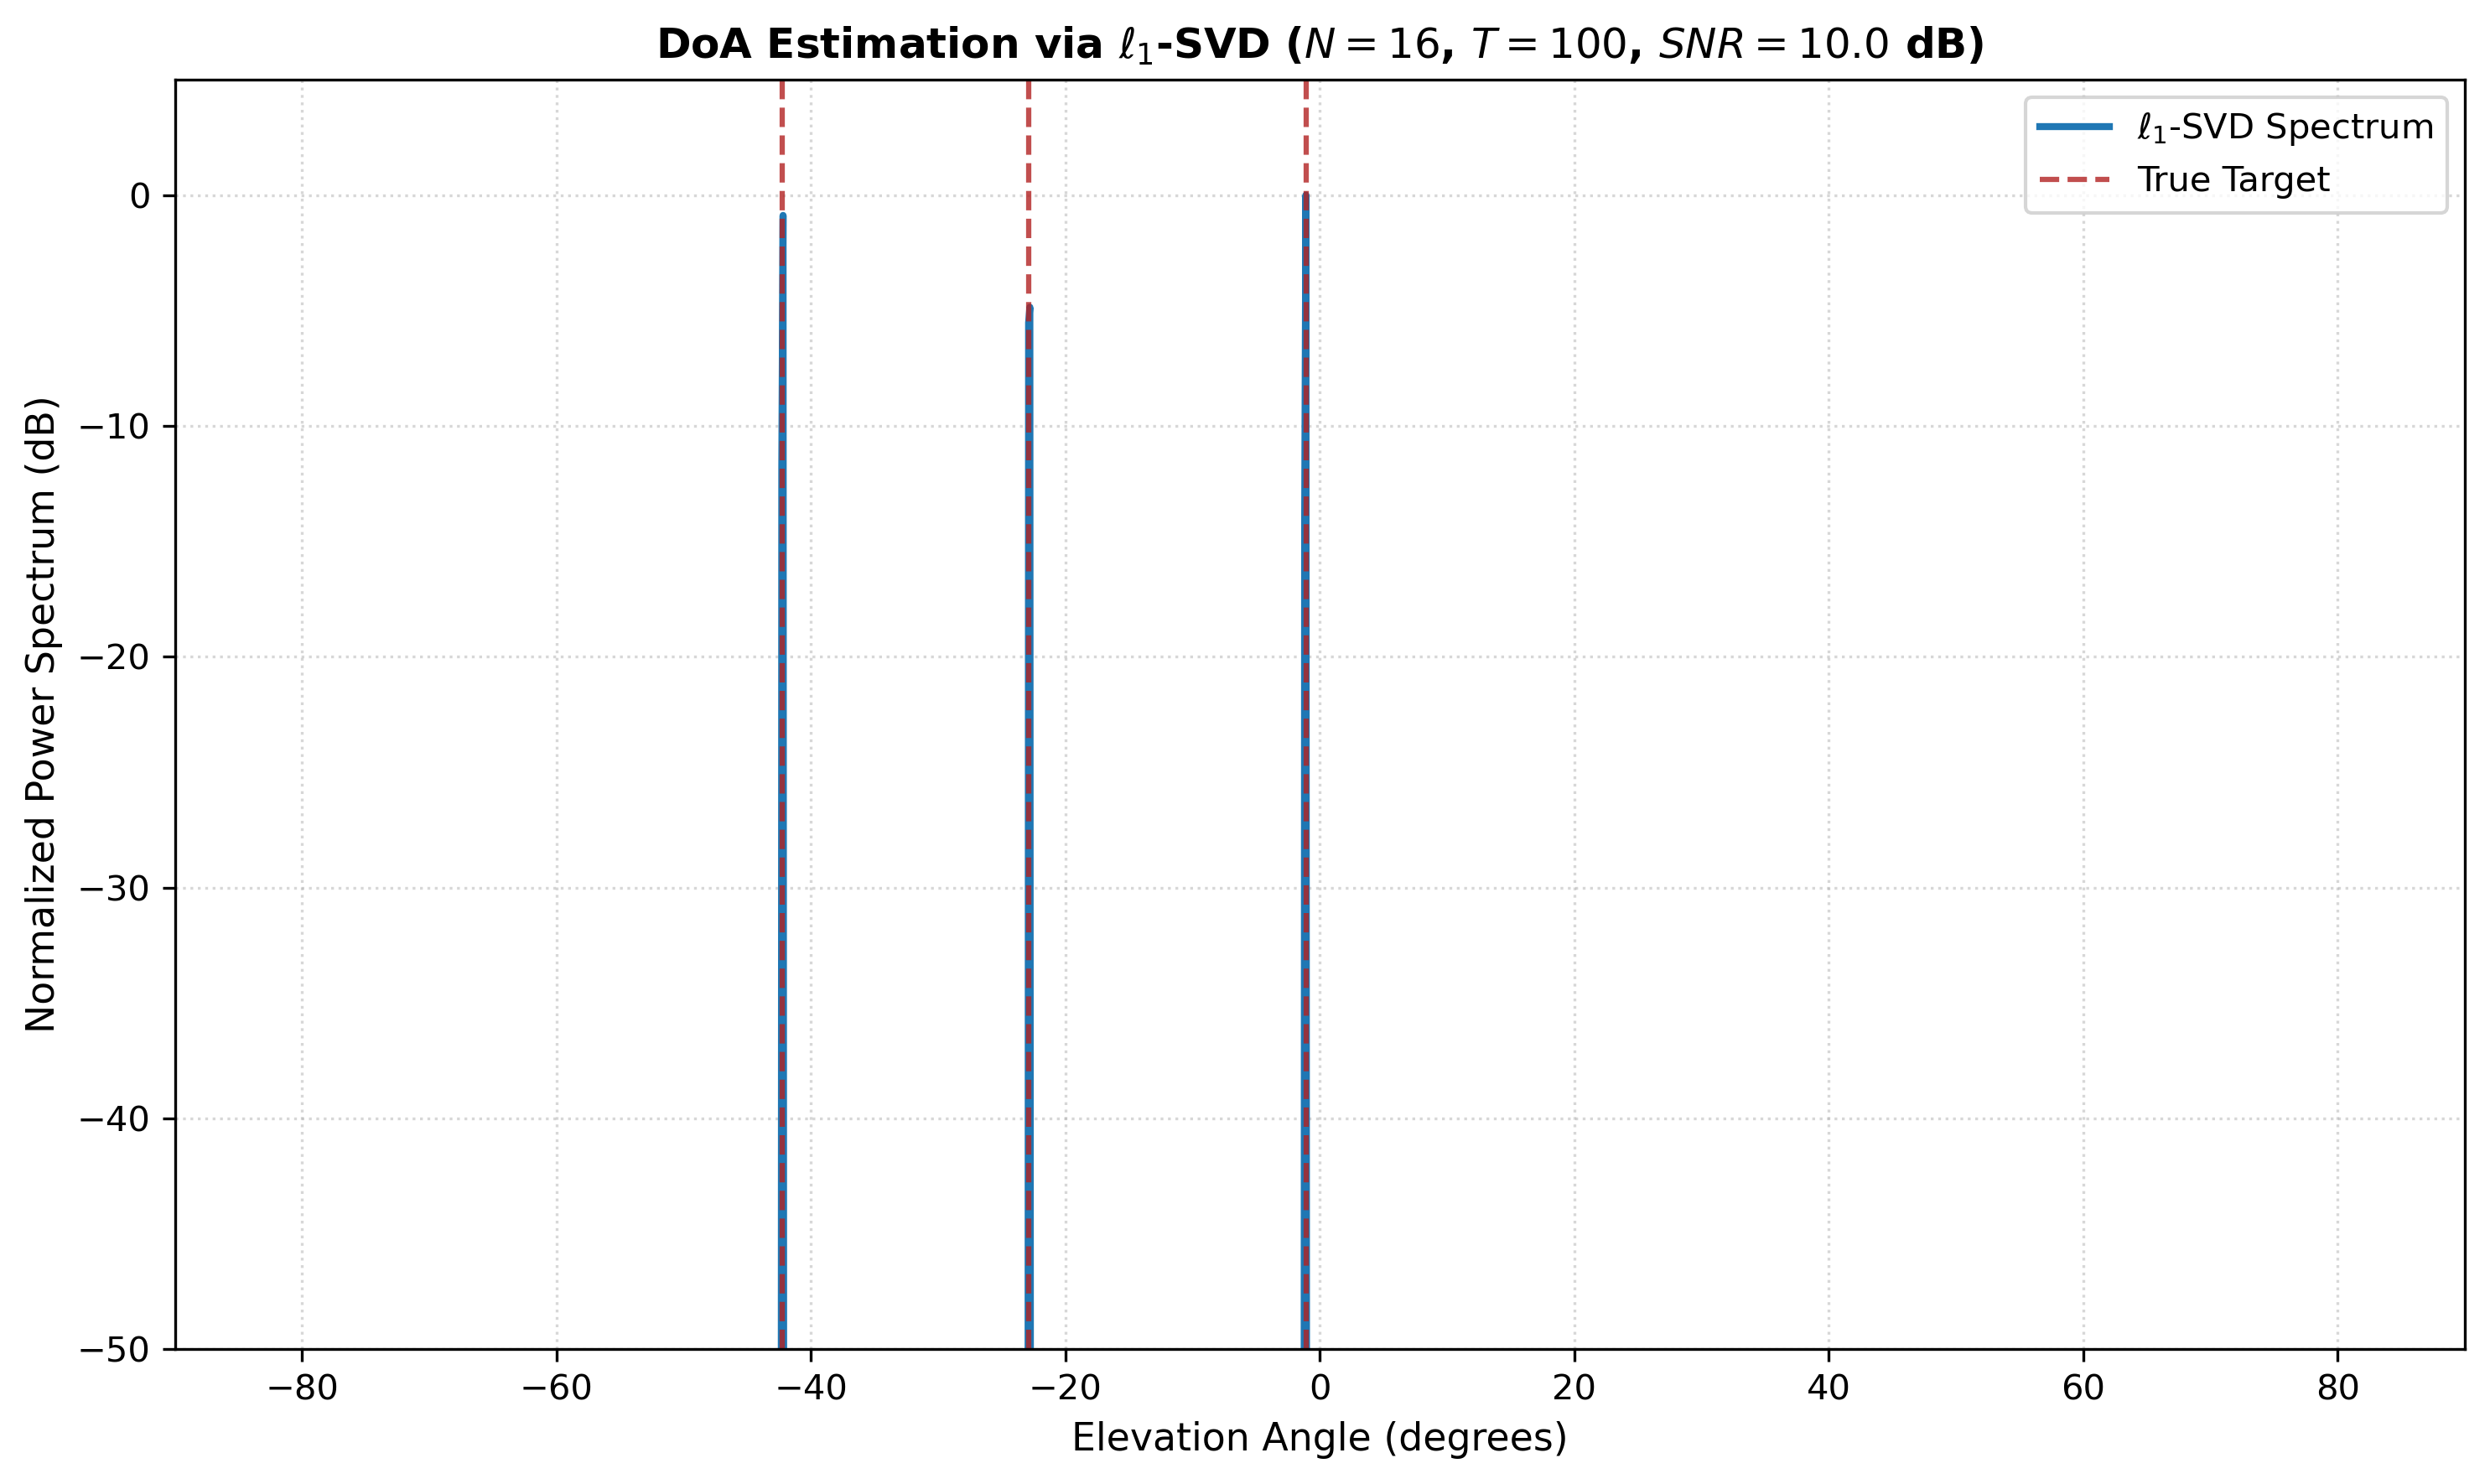

In [7]:
# Normalize and convert to decibels
spatial_spectrum_normalized = spatial_spectrum / np.max(spatial_spectrum); 
spatial_spectrum_db = 20 * np.log10(spatial_spectrum_normalized + 1e-10); 

# Plot the results
plt.figure(figsize=(10, 6), dpi=300); 
plt.plot(theta_scan, spatial_spectrum_db, label=r"$\ell_1$-SVD Spectrum", color="#1f77b4", linewidth=2); 

# Mark the ground truth target locations
for idx, true_angle in enumerate(true_angles):
    plt.axvline(
        x=true_angle, 
        color="firebrick", 
        linestyle="--", 
        alpha=0.8,
        label="True Target" if idx == 0 else ""
); 

plt.title(r"DoA Estimation via $\ell_1$-SVD "+f"($N={N}$, $T={T}$, $SNR={snr_db}$ dB)", fontsize=12, fontweight="bold"); 
plt.xlabel("Elevation Angle (degrees)", fontsize=11); 
plt.ylabel("Normalized Power Spectrum (dB)", fontsize=11); 
plt.xlim([-90, 90]); 
plt.ylim([-50, 5]); 
plt.grid(True, which="both", linestyle=":", alpha=0.5); 
plt.legend(loc="upper right", frameon=True); 
plt.tight_layout(); 
plt.show(); 

In [8]:
def doa_l1_svd(X, sensor_pos, grid_angles_deg, K, wl):
  N, T = X.shape; 
  M = len(grid_angles_deg); 
    
  A_grid = np.column_stack([steering_vector(sensor_pos, theta, 0, wl) for theta in np.deg2rad(grid_angles_deg)]); 
  
  # SVD reduction
  U, S, _ = np.linalg.svd(X, full_matrices=False); 
  X_SV = U[:, :K] @ np.diag(S[:K])  # SVD-reduced data matrix of size (N, K)
    
  # Formulating the optimization Problem
  S_SV = cp.Variable((M, K), complex=True); 
        
  row_norms = [cp.norm(S_SV[i, :], 2) for i in range(M)]; 
  objective = cp.Minimize(cp.sum(row_norms)); 
    
  deg_of_freedom = 2*N*K;                                 # Complex variables double the degrees of freedom
  chi2_threshold = chi2.ppf(0.99, df=deg_of_freedom); 
  beta = np.sqrt(noise_pow * chi2_threshold / 2);         # 99% chi-squared threshold
  #beta = np.linalg.norm(X_SV, 'fro'); 
        
  constraints = [cp.norm(X_SV - A_grid @ S_SV, 'fro') <= beta]; 
    
  # Solver
  prob = cp.Problem(objective, constraints); 
  prob.solve(solver=cp.SCS, verbose=False); 
    
  if prob.status not in ["optimal", "feasible"]:
    print(Warning(f"Solver terminated with status: {prob.status}. Trying alternative scale.")); 
    
  # Computing the final spatial spectrum by evaluating the L2 norm across the rows of S_SV
  spatial_spectrum = np.array([np.linalg.norm(S_SV.value[i, :], 2) for i in range(M)]); 
    
  return spatial_spectrum; 

Running L1-SVD DoA Estimation optimization...


/tmp/ipykernel_2591/1358468227.py:26: UserWarning: Objective contains too many subexpressions. Consider vectorizing your CVXPY code to speed up compilation.
  prob.solve(solver=cp.SCS, verbose=False);


Optimization completed successfully.


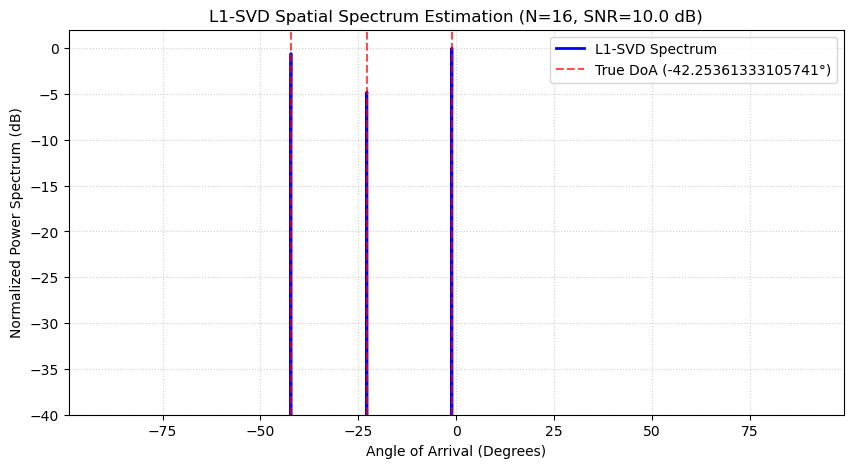

In [9]:
print("Running L1-SVD DoA Estimation optimization..."); 
spectrum = doa_l1_svd(X, sensor_pos, theta_scan, K, wl); 
print("Optimization completed successfully."); 

# Plotting Results
spectrum = spectrum / np.max(spectrum);  # Normalize spectrum for standard dB visualization

plt.figure(figsize=(10, 5))
plt.plot(theta_scan, 20 * np.log10(spectrum + 1e-6), label="L1-SVD Spectrum", color='b', lw=2); 

# Highlight true source locations
for doa in true_angles:
    plt.axvline(x=doa, 
                color='r', 
                linestyle='--', 
                alpha=0.7, 
                label=f"True DoA ({doa}°)" if doa == true_angles[0] else ""); 
    
plt.title(f"L1-SVD Spatial Spectrum Estimation (N={N}, SNR={snr_db} dB)"); 
plt.xlabel("Angle of Arrival (Degrees)"); 
plt.ylabel("Normalized Power Spectrum (dB)"); 
plt.grid(True, linestyle=':', alpha=0.6); 
plt.ylim([-40, 2]); 
plt.legend(loc="upper right"); 
plt.show(); 